In [38]:
import torch
data = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.001_results.pt", weights_only=False)
theta_stars = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.001_phi_oracle_hist.pt", weights_only=False)

In [39]:
phi_hist, oracle_hist, _ = theta_stars

In [6]:
data["BPC-BOCPD"].keys()

dict_keys(['theta', 'theta_oracle', 'others', 'rmse'])

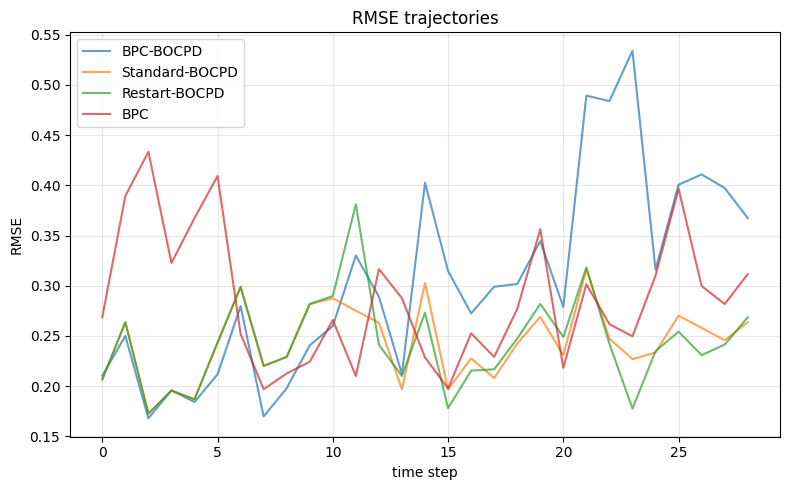

['BPC-BOCPD', 'Standard-BOCPD', 'Restart-BOCPD', 'BPC']
[0.30388321 0.24343526 0.24312915 0.28718998] [0.00952849 0.00131384 0.00202744 0.00420968] [0.09761396 0.03624696 0.04502715 0.06488205]


In [40]:
import numpy as np
import matplotlib.pyplot as plt

rmse_list = [data[name]["rmse"] for name in data.keys()]
names = [name for name in data.keys()]

plt.figure(figsize=(8, 5))

for i, rmse in enumerate(rmse_list):
    plt.plot(rmse, alpha=0.7, label=names[i])

plt.xlabel("time step")
plt.ylabel("RMSE")
plt.title("RMSE trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rmse_mat = np.stack(rmse_list, axis=0)  # shape = (N_runs, T)
rmse_mean = rmse_mat.mean(axis=1)   # shape (T,)
rmse_var  = rmse_mat.var(axis=1)    # shape (T,)
rmse_std  = rmse_mat.std(axis=1)
print(names)
print(rmse_mean, rmse_var, rmse_std)

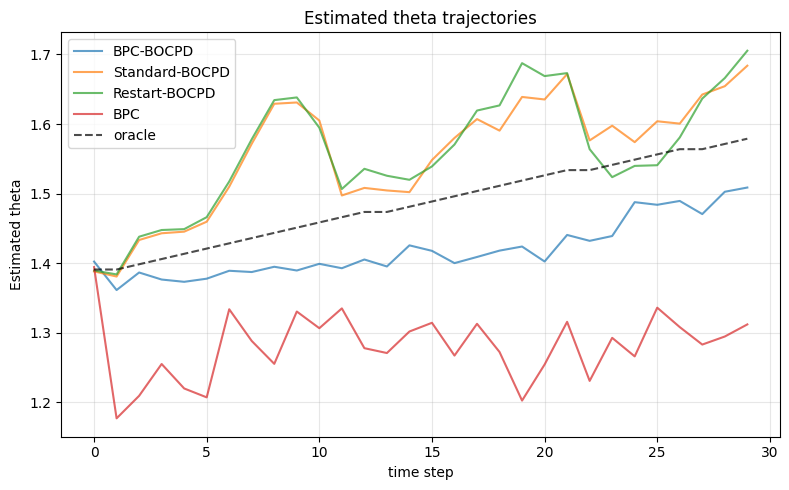

In [41]:
theta_list = []
for n in names:
    theta_list.append(data[n]['theta'])

plt.figure(figsize=(8, 5))

for i, theta in enumerate(theta_list):
    plt.plot(theta, alpha=0.7, label=names[i])

plt.plot(np.array(oracle_hist), alpha=0.7, label="oracle", color="black", linestyle="dashed")

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Estimated theta trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
theta_rmse_all = {}

for n in names:
    theta_n = np.asarray(data[n]["theta"])
    theta_rmse_all[n] = np.sqrt(np.mean((theta_n - oracle_hist) ** 2))

for k, v in theta_rmse_all.items():
    print(f"{k}: theta RMSE = {v:.4f}")


BPC-BOCPD: theta RMSE = 0.0723
Standard-BOCPD: theta RMSE = 0.0872
Restart-BOCPD: theta RMSE = 0.0948
BPC: theta RMSE = 0.2154


In [43]:
for n in names:
    try:
        others = data[n]["others"]

        lo = np.array([o["lo"] for o in others])
        hi = np.array([o["hi"] for o in others])
        oracle = np.asarray(oracle_hist)

        coverage = np.mean((oracle >= lo) & (oracle <= hi))
        print(f"{n}'s 90% coverage:", coverage)
    except:
        continue


BPC-BOCPD's 90% coverage: 0.051111111111111114
Standard-BOCPD's 90% coverage: 0.3333333333333333
Restart-BOCPD's 90% coverage: 0.3333333333333333


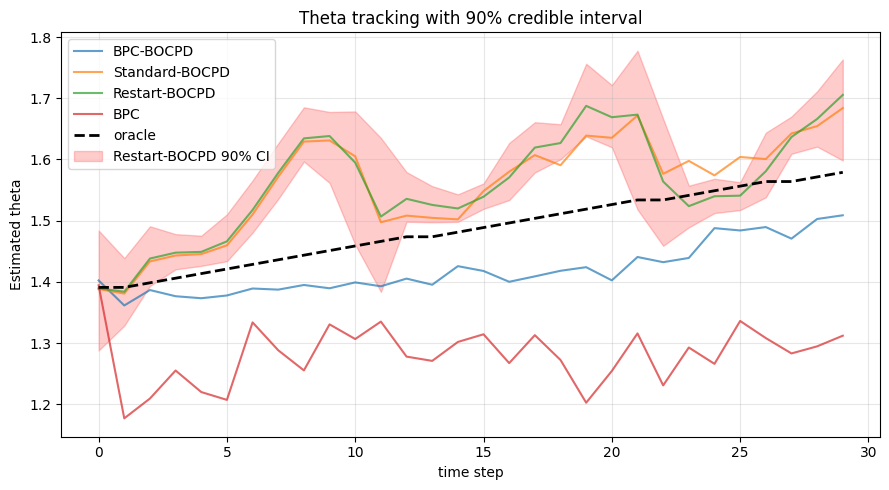

In [44]:
plt.figure(figsize=(9, 5))

# -------- point estimates --------
for i, n in enumerate(names):
    plt.plot(
        data[n]["theta"],
        alpha=0.7,
        label=n
    )

# -------- oracle --------
plt.plot(
    oracle_hist,
    color="black",
    linestyle="dashed",
    lw=2,
    label="oracle"
)

# -------- 90% credible interval (Restart-BOCPD) --------
others = data["Restart-BOCPD"]["others"]
lo = np.array([o["lo"] for o in others])
hi = np.array([o["hi"] for o in others])

t = np.arange(len(lo))
plt.fill_between(
    t,
    lo,
    hi,
    color="red",
    alpha=0.2,
    label="Restart-BOCPD 90% CI"
)

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Theta tracking with 90% credible interval")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
def extract_theta_and_ci(data_method, oracle_hist):
    """
    data_method: data[name]
    oracle_hist: (T,)
    
    returns:
        theta: (T,)
        lo: (T,) or None
        hi: (T,) or None
    """
    theta = np.asarray(data_method["theta"])
    T = len(theta)

    if "others" in data_method and len(data_method["others"]) == T:
        o0 = data_method["others"][0]
        if isinstance(o0, dict) and "lo" in o0 and "hi" in o0:
            lo = np.array([o["lo"] for o in data_method["others"]])
            hi = np.array([o["hi"] for o in data_method["others"]])
            return theta, lo, hi

    return theta, None, None


BPC-BOCPD       coverage = 0.051
Standard-BOCPD  coverage = 0.333
Restart-BOCPD   coverage = 0.333
BPC             coverage = N/A


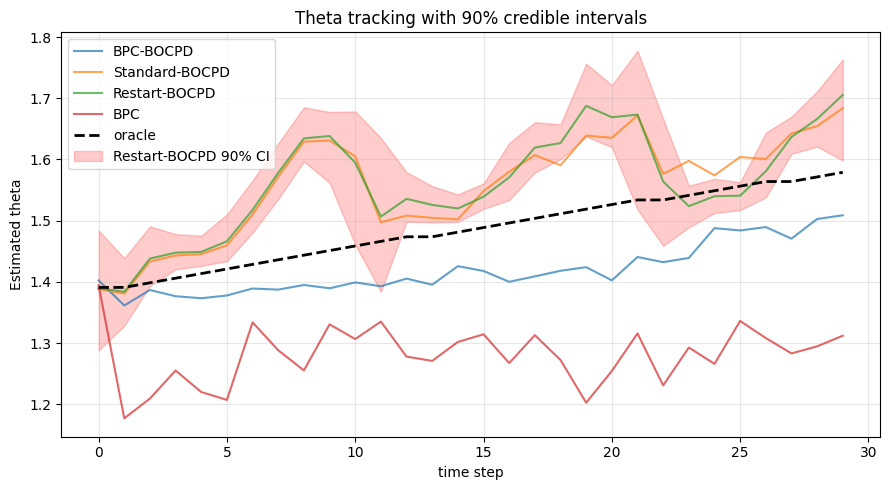

In [48]:
coverage_all = {}

for n in names:
    theta, lo, hi = extract_theta_and_ci(data[n], oracle_hist)
    if lo is None:
        coverage_all[n] = None
        continue

    oracle = oracle_hist[:len(theta)]
    coverage_all[n] = np.mean((oracle >= lo) & (oracle <= hi))

for k, v in coverage_all.items():
    if v is None:
        print(f"{k:15s} coverage = N/A")
    else:
        print(f"{k:15s} coverage = {v:.3f}")

plt.figure(figsize=(9, 5))

# -------- point estimates --------
for n in names:
    plt.plot(
        data[n]["theta"],
        alpha=0.7,
        label=n
    )

# -------- oracle --------
plt.plot(
    oracle_hist,
    color="black",
    linestyle="dashed",
    lw=2,
    label="oracle"
)

# -------- Restart-BOCPD CI --------
if "Restart-BOCPD" in data:
    _, lo_r, hi_r = extract_theta_and_ci(
        data["Restart-BOCPD"], oracle_hist
    )
    if lo_r is not None:
        t = np.arange(len(lo_r))
        plt.fill_between(
            t,
            lo_r,
            hi_r,
            color="red",
            alpha=0.2,
            label="Restart-BOCPD 90% CI"
        )

# -------- BPC-BOCPD CI --------
# if "BPC-BOCPD" in data:
#     _, lo_b, hi_b = extract_theta_and_ci(
#         data["BPC-BOCPD"], oracle_hist
#     )
#     if lo_b is not None:
#         lo_b = np.asarray(lo_b).squeeze()
#         hi_b = np.asarray(hi_b).squeeze()
        
#         t = np.arange(len(lo_b))
#         plt.fill_between(
#             t,
#             lo_b,
#             hi_b,
#             color="blue",
#             alpha=0.2,
#             label="BPC-BOCPD 90% CI"
#         )
# if "BPC-BOCPD" in data:
#     # 提取 mean / var
#     theta_mean = np.asarray(data["BPC-BOCPD"]["theta"]).squeeze()

#     # others[i]["var"] 可能是 scalar 或 array，统一成 1D
#     theta_var = np.array([
#         float(o["var"]) for o in data["BPC-BOCPD"]["others"]
#     ])

#     theta_std = np.sqrt(theta_var)

#     lo_b = theta_mean - 2.0 * theta_std
#     hi_b = theta_mean + 2.0 * theta_std

#     t = np.arange(len(theta_mean))
#     plt.fill_between(
#         t,
#         lo_b,
#         hi_b,
#         color="blue",
#         alpha=0.2,
#         label="BPC-BOCPD mean ± 2 std"
#     )

plt.xlabel("time step")
plt.ylabel("Estimated theta")
plt.title("Theta tracking with 90% credible intervals")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [57]:
for name in ["Restart-BOCPD", "Standard-BOCPD"]:
    lst = [x["did_restart"] for x in data[name]["others"]]
    count_true = sum(lst)
    avg_interval = len(lst)/count_true
    print(name, count_true, avg_interval)

Restart-BOCPD 2 15.0
Standard-BOCPD 7 4.285714285714286


In [1]:
import torch
prefix = "deltaCmp_v1"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_results.pt", weights_only=False)

color_map = {
    # ---- PF / BOCPD-PF variants ----
    "BOCPD-PF": "#1f77b4",                    # blue
    "R-BOCPD-PF": "#2ca02c",                  # green
    "R-BOCPD-PF-nodiscrepancy": "#ff7f0e",    # orange
    "R-BOCPD-PF-usediscrepancy": "#9467bd",   # purple

    # ---- BPC family ----
    "BPC-80": "#d62728",                      # red
    "BOCPD-BPC": "#8c564b",                   # brown
}




In [12]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (slope, bc, seed), res in results.items():
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]
        y_crps, theta_crps = res["y-crps"], res["theta_crps"]

        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                slope=slope,
                batch_size=bc,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                # restart_count=count_true if name=="Restart-BOCPD" else np.nan,
                # avg_restart_interval=avg_interval if name=="Restart-BOCPD" else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                y_crps=y_crps[name],
                theta_crps=theta_crps[name],
            ))
    return pd.DataFrame(rows)

df = flatten_results(results)
df = df[df["slope"] < 0.008]

print(df.head())


   slope  batch_size  seed                     method  rmse_mean  rmse_std  \
0  0.001          10   456                     BPC-80   1.557957  0.173305   
1  0.001          10   456                  BOCPD-BPC   1.578715  0.184874   
2  0.001          10   456                   BOCPD-PF   1.644223  0.202008   
3  0.001          10   456  R-BOCPD-PF-usediscrepancy   1.622910  0.179432   
4  0.001          10   456   R-BOCPD-PF-nodiscrepancy   1.582615  0.171298   

   theta_rmse  coverage  restart_count  avg_restart_interval    y_crps  \
0    0.054282       NaN            NaN                   NaN  1.237481   
1    0.086841  0.048889            NaN                   NaN  1.253747   
2    0.157652  0.733333            NaN                   NaN  1.220356   
3    0.132313  0.800000            8.0                   7.5  1.214989   
4    0.038510  1.000000            0.0                   NaN  1.212332   

   theta_crps  
0    0.051133  
1    0.053963  
2    0.080764  
3    0.039982  
4    0

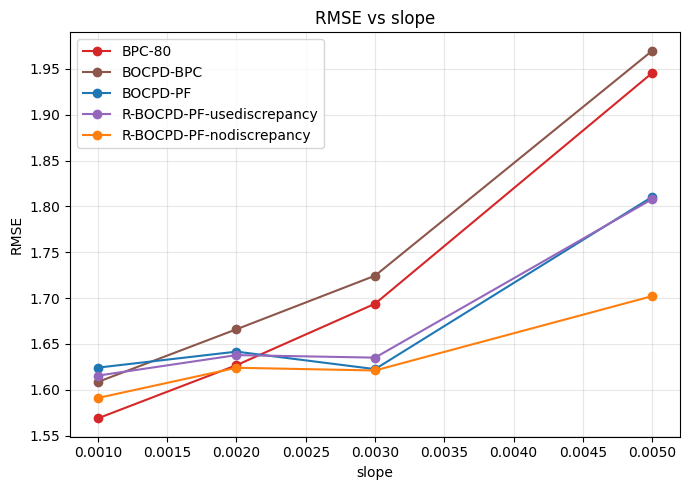

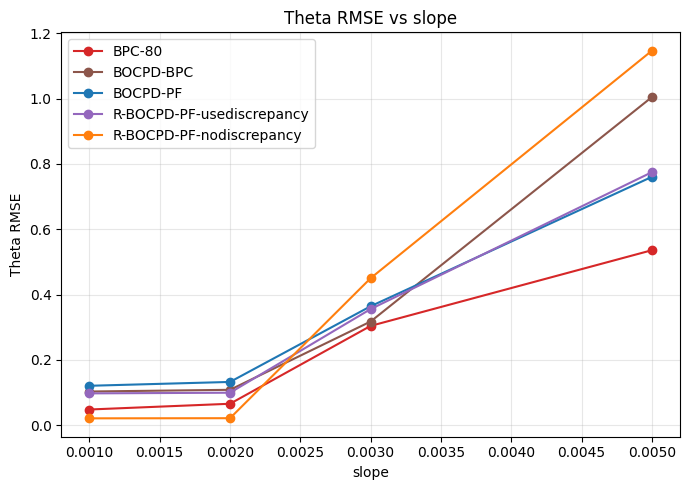

In [13]:
import matplotlib.pyplot as plt

def plot_metric_vs_slope(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("slope")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("slope")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_{metric}_vs_slope.png")
    plt.show()

plot_metric_vs_slope(df, "rmse_mean", "RMSE")
plot_metric_vs_slope(df, "theta_rmse", "Theta RMSE")


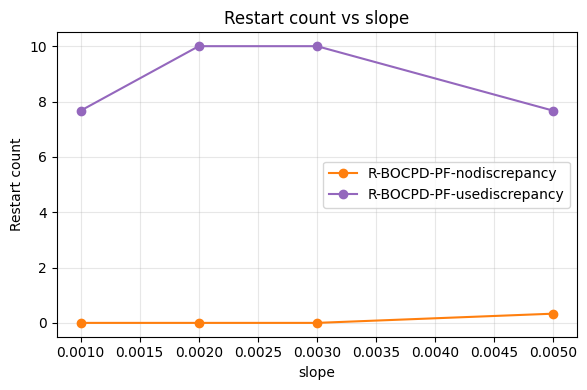

In [14]:
def plot_restart_vs_slope(df):
    d = df[df["method"]=="R-BOCPD-PF-nodiscrepancy"]
    g = d.groupby("slope")["restart_count"].mean()

    d1 = df[df["method"]=="R-BOCPD-PF-usediscrepancy"]
    g1 = d1.groupby("slope")["restart_count"].mean()

    plt.figure(figsize=(6,4))
    plt.plot(g.index, g.values, marker="o", label="R-BOCPD-PF-nodiscrepancy", color=color_map["R-BOCPD-PF-nodiscrepancy"])
    plt.plot(g1.index, g1.values, marker="o", label="R-BOCPD-PF-usediscrepancy", color=color_map["R-BOCPD-PF-usediscrepancy"])
    plt.xlabel("slope")
    plt.ylabel("Restart count")
    plt.title("Restart count vs slope")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_restart_vs_slope.png")
    plt.show()

plot_restart_vs_slope(df)


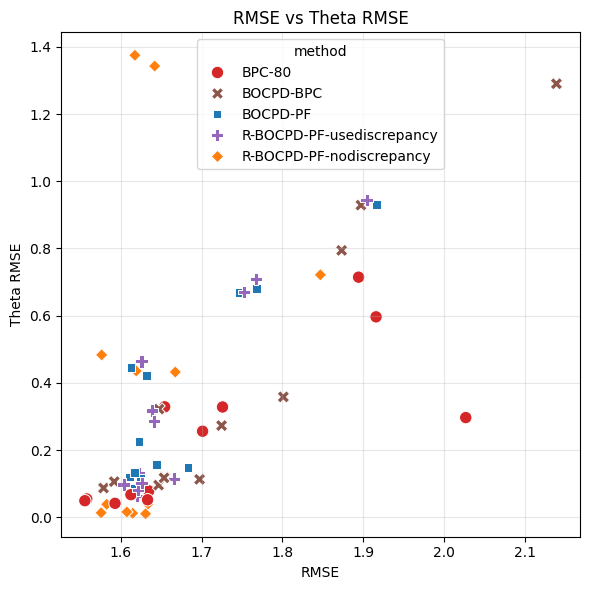

In [15]:
import seaborn as sns

def scatter_rmse_theta(df):
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        data=df,
        x="rmse_mean",
        y="theta_rmse",
        hue="method",
        style="method",
        s=80,
        palette=color_map
    )
    plt.xlabel("RMSE")
    plt.ylabel("Theta RMSE")
    plt.title("RMSE vs Theta RMSE")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_rmse_vs_theta_rmse_scatter.png")
    plt.show()

scatter_rmse_theta(df)


In [9]:
def compute_rank(df, metric):
    ranks = []
    for slope in df["slope"].unique():
        d = df[df["slope"]==slope]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                slope=slope,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank(df, "rmse_mean")
rank_theta = compute_rank(df, "theta_rmse")
rank_ycrps  = compute_rank(df, "y_crps")
rank_thetacrps = compute_rank(df, "theta_crps")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.166667
R-BOCPD-PF-usediscrepancy    2.833333
BOCPD-PF                     3.500000
BPC-80                       3.500000
BOCPD-BPC                    4.000000
Name: rank, dtype: float64

Theta RMSE rank:
method
BPC-80                       1.666667
R-BOCPD-PF-usediscrepancy    2.833333
R-BOCPD-PF-nodiscrepancy     3.000000
BOCPD-BPC                    3.333333
BOCPD-PF                     4.166667
Name: rank, dtype: float64


In [16]:
print("y-CPRS rank:")
print(rank_ycrps.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_thetacrps.groupby("method")["rank"].mean().sort_values())

y-CPRS rank:
method
R-BOCPD-PF-usediscrepancy    1.833333
BOCPD-PF                     2.166667
R-BOCPD-PF-nodiscrepancy     2.333333
BOCPD-BPC                    4.333333
BPC-80                       4.333333
Name: rank, dtype: float64

Theta RMSE rank:
method
BPC-80                       2.000000
BOCPD-BPC                    2.333333
R-BOCPD-PF-nodiscrepancy     3.000000
R-BOCPD-PF-usediscrepancy    3.333333
BOCPD-PF                     4.333333
Name: rank, dtype: float64


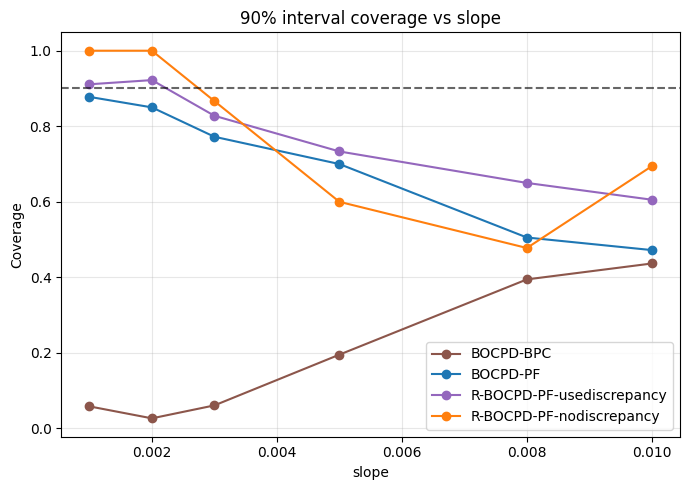

In [11]:
def plot_coverage(df):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        # method = "Restart-BOCPD"
        d = df[df["method"]==method]
        if d["coverage"].isna().all():
            continue
        m = d.groupby("slope")["coverage"].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])
    # method = "Restart-BOCPD"
    # d = df[df["method"]==method]
    # # if d["coverage"].isna().all():
    # #     continue
    # m = d.groupby("slope")["coverage"].mean()
    # plt.plot(m.index, m.values, marker="o", label=method)

    plt.axhline(0.9, color="k", linestyle="--", alpha=0.6)
    plt.xlabel("slope")
    plt.ylabel("Coverage")
    plt.title("90% interval coverage vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_coverage_vs_slope.png")
    plt.show()

plot_coverage(df)


In [91]:
df

,slope,batch_size,seed,method,rmse_mean,rmse_std,theta_rmse,coverage,restart_count,avg_restart_interval
0,0.001,20,456,BPC-BOCPD,0.305974,0.087762,0.062366,0.054444,NaN,NaN
1,0.001,20,456,Standard-BOCPD,0.237596,0.038634,0.105137,0.266667,NaN,NaN
2,0.001,20,456,Restart-BOCPD,0.228762,0.037224,0.103449,0.266667,3.0,10.000000
3,0.001,20,456,BPC,0.283432,0.078345,0.211136,NaN,NaN,NaN
4,0.001,40,456,BPC-BOCPD,0.359598,0.102758,0.074586,0.053333,NaN,NaN
5,0.001,40,456,Standard-BOCPD,0.270368,0.034220,0.069147,0.200000,NaN,NaN
6,0.001,40,456,Restart-BOCPD,0.257852,0.040808,0.048290,0.600000,3.0,5.000000
7,0.001,40,456,BPC,0.288762,0.041965,0.211573,NaN,NaN,NaN
8,0.002,20,456,BPC-BOCPD,0.419656,0.134013,0.049560,0.040000,NaN,NaN
9,0.002,20,456,Standard-BOCPD,0.265113,0.046424,0.072961,0.433333,NaN,NaN


In [72]:
debug_res = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/slope_0.005_seed456_batch40_results.pt", weights_only=False)


In [124]:
phi = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_v6/slope_0.008_seed456_batch40_phi_oracle_hist.pt", weights_only=False)

In [125]:
phi

{'phi_hist': [array([5., 5., 5.]),
  array([5.  , 5.32, 5.  ]),
  array([5.  , 5.64, 5.  ]),
  array([5.  , 5.96, 5.  ]),
  array([5.  , 6.28, 5.  ]),
  array([5. , 6.6, 5. ]),
  array([5.  , 6.92, 5.  ]),
  array([5.  , 7.24, 5.  ]),
  array([5.  , 7.56, 5.  ]),
  array([5.  , 7.88, 5.  ]),
  array([5. , 8.2, 5. ]),
  array([5.  , 8.52, 5.  ]),
  array([5.  , 8.84, 5.  ]),
  array([5.  , 9.16, 5.  ]),
  array([5.  , 9.48, 5.  ])],
 'oracle_hist': [1.3909774436090225,
  1.4962406015037593,
  1.593984962406015,
  1.6616541353383458,
  1.706766917293233,
  1.7518796992481203,
  1.789473684210526,
  1.8345864661654134,
  1.8872180451127818,
  1.9548872180451127,
  2.037593984962406,
  2.1353383458646613,
  2.218045112781955,
  2.2857142857142856,
  2.338345864661654]}

In [80]:
debug_res["Restart-BOCPD"]['others'][-4:], debug_res["Restart-BOCPD"]['theta'][-4:]

([{'did_restart': False,
   'var': 0.0007023502944285244,
   'lo': 1.8348981142044067,
   'hi': 1.9172669513914835},
  {'did_restart': True,
   'var': 0.5966463821957984,
   'lo': 0.26110900613451404,
   'hi': 1.9133268129081158},
  {'did_restart': False,
   'var': 0.015478940596340482,
   'lo': 0.1709764007719303,
   'hi': 0.24189859628677368},
  {'did_restart': True,
   'var': 0.0016068974853185292,
   'lo': 1.898771355788596,
   'hi': 2.030345527194764}],
 array([1.87097415, 1.13691184, 0.21692365, 1.96626833]))

In [20]:
import torch
prefix = "v1"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_results.pt", weights_only=False)

In [23]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (seg_len_L, delta_mag, batch_size, seed), res in results.items():
    # for t, res in results.items():
        # print(t)
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]
        count_true1, avg_interval1 = res["restart1"]
        y_crps, theta_crps = res["y-crps"], res["theta_crps"]
        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                seg_len_L=seg_len_L,
                delta_mag=delta_mag,
                batch_size=batch_size,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                y_crps=y_crps[name],
                theta_crps=theta_crps[name],
            ))
    return pd.DataFrame(rows)

df1 = flatten_results(results)
print(df1.head())


   seg_len_L  delta_mag  batch_size  seed                     method  \
0         80        0.5          20   456                   BOCPD-PF   
1         80        0.5          20   456                     BPC-80   
2         80        0.5          20   456                  BOCPD-BPC   
3         80        0.5          20   456  R-BOCPD-PF-usediscrepancy   
4         80        0.5          20   456   R-BOCPD-PF-nodiscrepancy   

   rmse_mean  rmse_std  theta_rmse  coverage  restart_count  \
0   1.705259  0.146591    0.077726    0.8750            NaN   
1   1.668481  0.135855    0.060918    0.0000            NaN   
2   1.695525  0.124367    0.102651    0.4375            NaN   
3   1.691904  0.146795    0.031695    1.0000            3.0   
4   1.687540  0.143457    0.010578    1.0000            0.0   

   avg_restart_interval    y_crps  theta_crps  
0                   NaN  1.287489    0.048852  
1                   NaN  1.317593    0.056518  
2                   NaN  1.335108    0.07219

In [31]:
final_df = summarize_rank(df1, compute_rank_magnitude)
final_df

,method,theta_crps_x,y_crps_x,theta_rmse_x,rmse_mean_x,rmse_mean_y,theta_crps_y,theta_rmse_y,y_crps_y
0,BOCPD-BPC,0.054907,1.318055,0.068380,1.686553,2.25,4.25,3.25,4.25
1,BOCPD-PF,0.049630,1.302177,0.085010,1.727525,4.50,3.25,3.75,3.25
2,BPC-80,0.070704,1.347454,0.108407,1.718004,3.00,4.50,4.00,4.50
3,R-BOCPD-PF-nodiscrepancy,0.028180,1.284177,0.018581,1.694997,2.00,1.00,1.25,1.50
4,R-BOCPD-PF-usediscrepancy,0.033151,1.283234,0.040479,1.702530,3.25,2.00,2.75,1.50


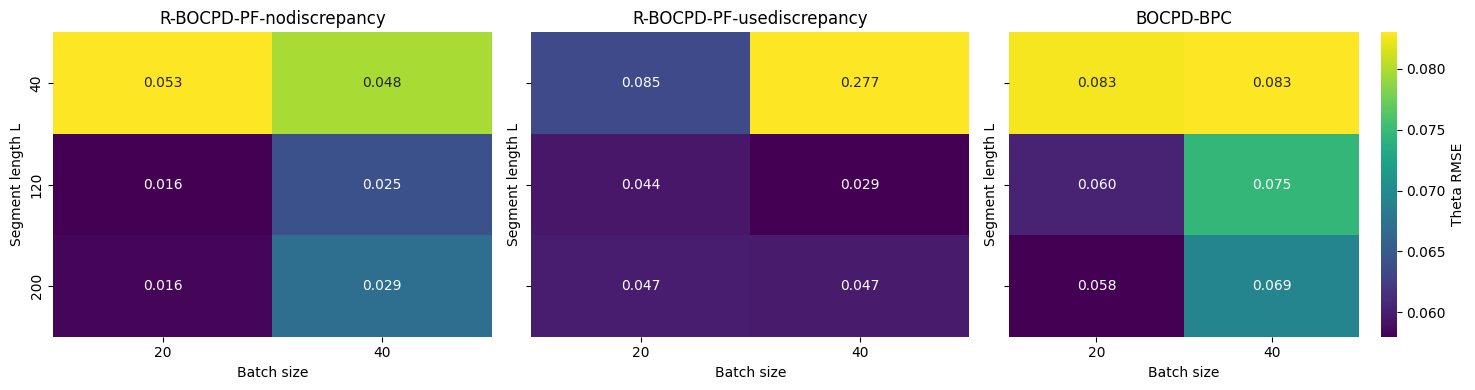

In [204]:
def plot_theta_rmse_heatmap_multi(df, methods, cmap="viridis"):
    n = len(methods)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, method in zip(axes, methods):
        d = df[df["method"] == method]
        mat = d.pivot_table(
            index="seg_len_L",
            columns="batch_size",
            values="theta_rmse",
            aggfunc="mean"
        )

        sns.heatmap(
            mat,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            ax=ax,
            cbar=ax is axes[-1],  # 只在最后一个画 colorbar
            cbar_kws={"label": "Theta RMSE"},
        )
        ax.set_title(method)
        ax.set_xlabel("Batch size")
        ax.set_ylabel("Segment length L")

    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_theta_rmse_heatmap_multi.png")
    plt.show()

methods = [
    "R-BOCPD-PF-nodiscrepancy",
    "R-BOCPD-PF-usediscrepancy",
    "BOCPD-BPC",
]
plot_theta_rmse_heatmap_multi(df, methods)


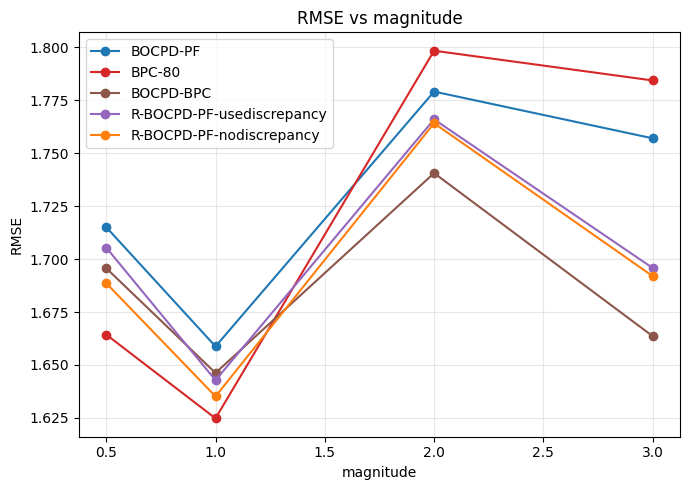

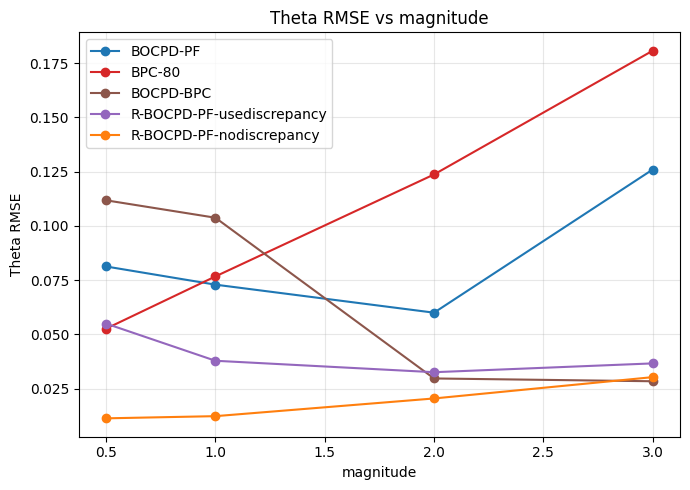

In [64]:
import matplotlib.pyplot as plt

def plot_metric_vs_magnitude(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("delta_mag")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("magnitude")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_{metric}_vs_magnitude.png")
    plt.show()

plot_metric_vs_magnitude(df, "rmse_mean", "RMSE")
plot_metric_vs_magnitude(df, "theta_rmse", "Theta RMSE")


In [47]:
import matplotlib.pyplot as plt

def plot_metric_vs_variable(df, metric, ylabel, variable="magnitude"):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby(variable)[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel(variable)
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs {variable}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_{metric}_vs_{variable}.png")
    plt.show()

# plot_metric_vs_variable(df, "rmse_mean", "RMSE", "seg_len_L")
# plot_metric_vs_variable(df, "theta_rmse", "Theta RMSE", "seg_len_L")


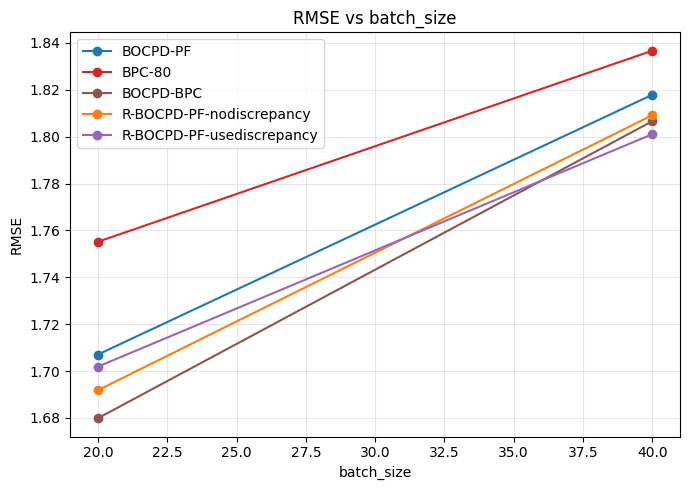

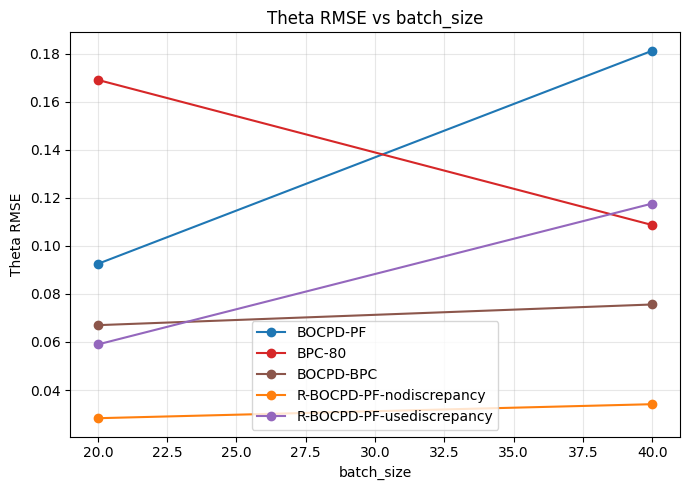

In [208]:
plot_metric_vs_variable(df, "rmse_mean", "RMSE", "batch_size")
plot_metric_vs_variable(df, "theta_rmse", "Theta RMSE", "batch_size")

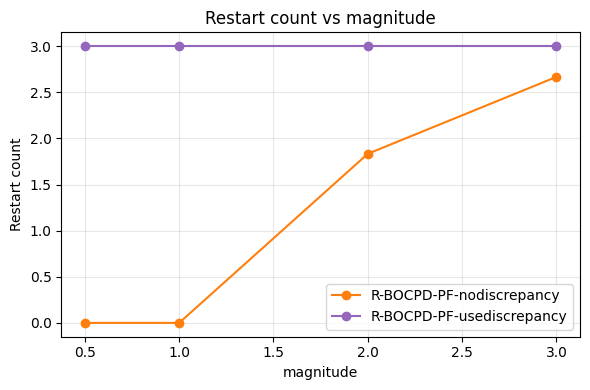

In [23]:
def plot_restart_vs_magnitude(df):
    d = df[df["method"]=="R-BOCPD-PF-nodiscrepancy"]
    g = d.groupby("delta_mag")["restart_count"].mean()
    d1 = df[df["method"]=="R-BOCPD-PF-usediscrepancy"]
    g1 = d1.groupby("delta_mag")["restart_count"].mean()

    plt.figure(figsize=(6,4))
    plt.plot(g.index, g.values, marker="o", label="R-BOCPD-PF-nodiscrepancy", color=color_map["R-BOCPD-PF-nodiscrepancy"])
    plt.plot(g1.index, g1.values, marker="o", label="R-BOCPD-PF-usediscrepancy", color=color_map["R-BOCPD-PF-usediscrepancy"])
    plt.xlabel("magnitude")
    plt.ylabel("Restart count")
    plt.title("Restart count vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_{prefix}/sudden_{prefix}_restart_vs_magnitude.png")
    plt.show()

plot_restart_vs_magnitude(df)


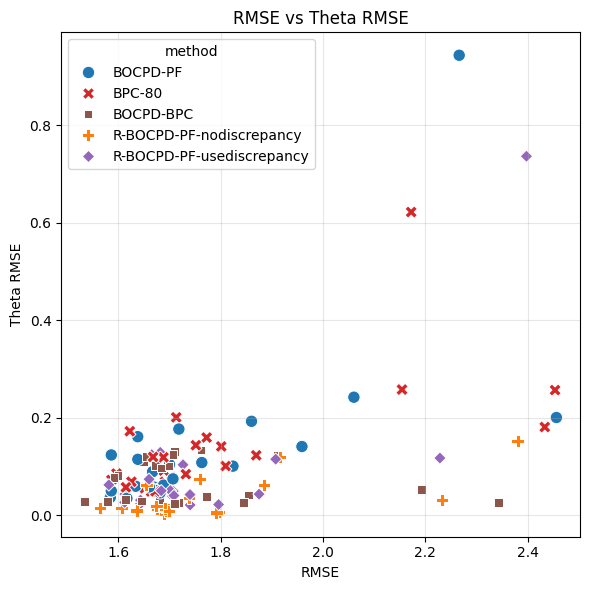

In [182]:
import seaborn as sns
scatter_rmse_theta(df)


In [28]:
def compute_rank_magnitude(df, metric):
    ranks = []
    for delta_mag in df["delta_mag"].unique():
        d = df[df["delta_mag"]==delta_mag]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                delta_mag=delta_mag,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank_magnitude(df, "rmse_mean")
rank_theta = compute_rank_magnitude(df, "theta_rmse")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     2.00
BOCPD-BPC                    2.25
BPC-80                       3.00
R-BOCPD-PF-usediscrepancy    3.25
BOCPD-PF                     4.50
Name: rank, dtype: float64

Theta RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.25
R-BOCPD-PF-usediscrepancy    2.75
BOCPD-BPC                    3.25
BOCPD-PF                     3.75
BPC-80                       4.00
Name: rank, dtype: float64


In [66]:
rank_ycrps  = compute_rank_magnitude(df, "y_crps")
rank_thetacrps = compute_rank_magnitude(df, "theta_crps")

print("y-CRPS rank:")
print(rank_ycrps.groupby("method")["rank"].mean().sort_values())

print("\nTheta CRPS rank:")
print(rank_thetacrps.groupby("method")["rank"].mean().sort_values())

y-CRPS rank:
method
R-BOCPD-PF-nodiscrepancy     1.50
R-BOCPD-PF-usediscrepancy    1.50
BOCPD-PF                     3.25
BOCPD-BPC                    4.25
BPC-80                       4.50
Name: rank, dtype: float64

Theta CRPS rank:
method
R-BOCPD-PF-nodiscrepancy     1.00
R-BOCPD-PF-usediscrepancy    2.00
BOCPD-PF                     3.25
BOCPD-BPC                    4.25
BPC-80                       4.50
Name: rank, dtype: float64


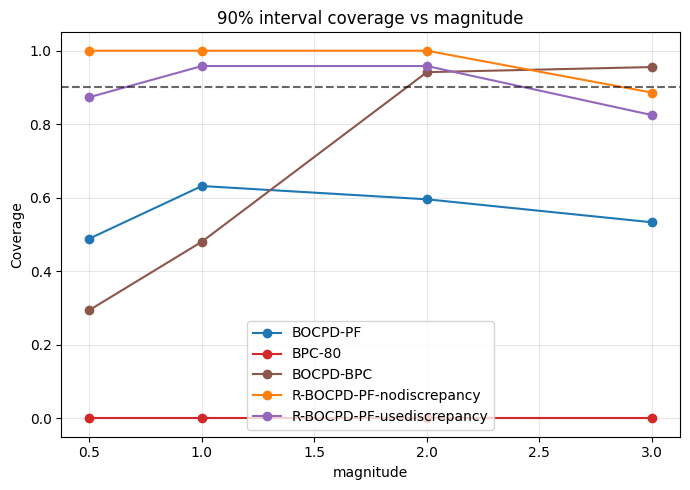

In [184]:
def plot_coverage_magnitude(df):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        # method = "Restart-BOCPD"
        d = df[df["method"]==method]
        if d["coverage"].isna().all():
            continue
        m = d.groupby("delta_mag")["coverage"].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])
    # method = "Restart-BOCPD"
    # d = df[df["method"]==method]
    # # if d["coverage"].isna().all():
    # #     continue
    # m = d.groupby("slope")["coverage"].mean()
    # plt.plot(m.index, m.values, marker="o", label=method)

    plt.axhline(0.9, color="k", linestyle="--", alpha=0.6)
    plt.xlabel("magnitude")
    plt.ylabel("Coverage")
    plt.title("90% interval coverage vs magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_coverage_magnitude(df)


In [37]:
import torch
prefix = "deltaCmp_v2"
results = torch.load(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_{prefix}/slope_{prefix}_results.pt", weights_only=False)

color_map = {
    # ---- PF / BOCPD-PF variants ----
    "BOCPD-PF": "#1f77b4",                    # blue
    "R-BOCPD-PF": "#2ca02c",                  # green
    "R-BOCPD-PF-nodiscrepancy": "#ff7f0e",    # orange
    "R-BOCPD-PF-usediscrepancy": "#9467bd",   # purple

    # ---- BPC family ----
    "BPC-80": "#d62728",                      # red
    "BOCPD-BPC": "#8c564b",                   # brown
}

In [34]:
import numpy as np
import pandas as pd

def flatten_results(results):
    rows = []
    for (slope, bc, seed), res in results.items():
        names, rmse_mean, rmse_var, rmse_std = res["rmse"]
        _, theta_rmse_all, coverage_all, lo_all, hi_all = res["theta"]
        count_true, avg_interval = res["restart"]
        count_true1, avg_interval1 = res["restart1"]
        y_crps, theta_crps = res["y-crps"], res["theta_crps"]

        for i, name in enumerate(names):
            # print(coverage_all[name])
            rows.append(dict(
                slope=slope,
                batch_size=bc,
                seed=seed,
                method=name,
                rmse_mean=float(rmse_mean[i]),
                rmse_std=float(rmse_std[i]),
                theta_rmse=float(theta_rmse_all[name]),
                coverage=float(coverage_all[name]) if (name in coverage_all and coverage_all[name] is not None) else np.nan,
                # restart_count=count_true if name=="Restart-BOCPD" else np.nan,
                # avg_restart_interval=avg_interval if name=="Restart-BOCPD" else np.nan,
                restart_count=count_true if name=="R-BOCPD-PF-nodiscrepancy" else (count_true1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                avg_restart_interval=avg_interval if name=="R-BOCPD-PF-nodiscrepancy" else (avg_interval1 if name=="R-BOCPD-PF-usediscrepancy" else np.nan),
                y_crps=y_crps[name],
                theta_crps=theta_crps[name],
            ))
    return pd.DataFrame(rows)

df = flatten_results(results)
print(df.head())


    slope  batch_size  seed                     method  rmse_mean  rmse_std  \
0  0.0005          10   456                     BPC-80   1.480337  0.195380   
1  0.0005          10   456                  BOCPD-BPC   1.486982  0.196421   
2  0.0005          10   456                   BOCPD-PF   1.556104  0.205688   
3  0.0005          10   456  R-BOCPD-PF-usediscrepancy   1.550543  0.205425   
4  0.0005          10   456   R-BOCPD-PF-nodiscrepancy   1.511662  0.205145   

   theta_rmse  coverage  restart_count  avg_restart_interval    y_crps  \
0    0.042704       NaN            NaN                   NaN  1.153818   
1    0.051068  0.079444            NaN                   NaN  1.158727   
2    0.111845  0.900000            NaN                   NaN  1.171446   
3    0.106180  0.900000            5.0                  12.0  1.167087   
4    0.034207  1.000000            0.0                   NaN  1.160835   

   theta_crps  
0    0.058039  
1    0.059279  
2    0.062770  
3    0.039289  


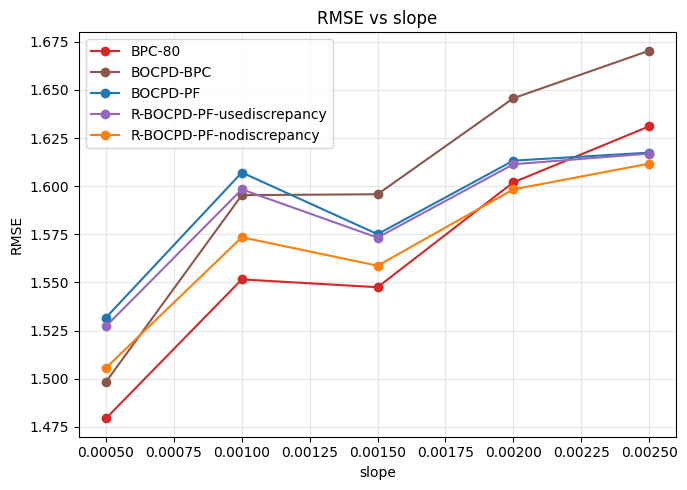

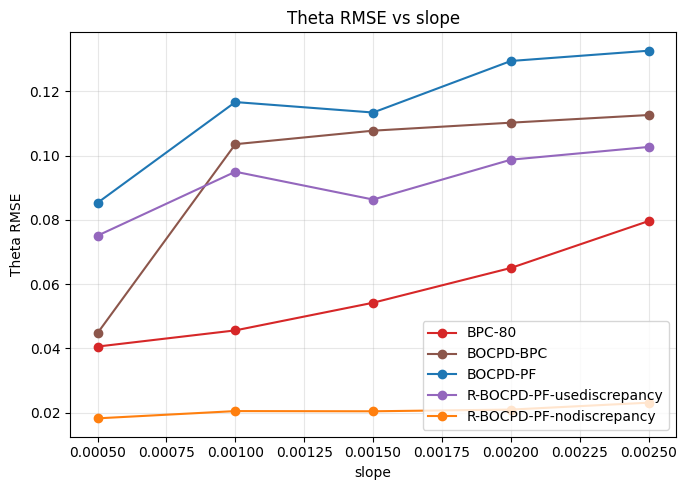

In [3]:
import matplotlib.pyplot as plt

def plot_metric_vs_slope(df, metric, ylabel):
    plt.figure(figsize=(7,5))
    for method in df["method"].unique():
        d = df[df["method"]==method]
        m = d.groupby("slope")[metric].mean()
        plt.plot(m.index, m.values, marker="o", label=method, color=color_map[method])

    plt.xlabel("slope")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs slope")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric_vs_slope(df, "rmse_mean", "RMSE")
plot_metric_vs_slope(df, "theta_rmse", "Theta RMSE")


In [4]:
def compute_rank(df, metric):
    ranks = []
    for slope in df["slope"].unique():
        d = df[df["slope"]==slope]
        order = d.groupby("method")[metric].mean().rank(method="average")
        for m, r in order.items():
            ranks.append(dict(
                slope=slope,
                method=m,
                metric=metric,
                rank=r
            ))
    return pd.DataFrame(ranks)

rank_rmse  = compute_rank(df, "rmse_mean")
rank_theta = compute_rank(df, "theta_rmse")

print("RMSE rank:")
print(rank_rmse.groupby("method")["rank"].mean().sort_values())

print("\nTheta RMSE rank:")
print(rank_theta.groupby("method")["rank"].mean().sort_values())



RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.8
BPC-80                       1.8
R-BOCPD-PF-usediscrepancy    3.2
BOCPD-BPC                    4.0
BOCPD-PF                     4.2
Name: rank, dtype: float64

Theta RMSE rank:
method
R-BOCPD-PF-nodiscrepancy     1.0
BPC-80                       2.0
R-BOCPD-PF-usediscrepancy    3.2
BOCPD-BPC                    3.8
BOCPD-PF                     5.0
Name: rank, dtype: float64


In [15]:
summary_df = (
    df
    .groupby("method")[["theta_crps", "y_crps", "theta_rmse", "rmse_mean"]]
    .mean()
    .reset_index()
)

print(summary_df)



                      method  theta_crps    y_crps  theta_rmse  rmse_mean
0                  BOCPD-BPC    0.048161  1.275442    0.095792   1.601137
1                   BOCPD-PF    0.053282  1.193284    0.115501   1.588945
2                     BPC-80    0.046689  1.244086    0.056996   1.562333
3   R-BOCPD-PF-nodiscrepancy    0.028574  1.207718    0.020613   1.569595
4  R-BOCPD-PF-usediscrepancy    0.037510  1.196817    0.091560   1.585464


In [30]:
def summarize_rank(df, func_rank):
    rank_rmse       = func_rank(df, "rmse_mean")
    rank_theta      = func_rank(df, "theta_rmse")
    rank_ycrps      = func_rank(df, "y_crps")
    rank_thetacrps  = func_rank(df, "theta_crps")

    # 合并
    rank_all = pd.concat([
        rank_rmse,
        rank_theta,
        rank_ycrps,
        rank_thetacrps
    ])

    # 计算每个 method 每个 metric 的平均 rank
    rank_summary = (
        rank_all
        .groupby(["method", "metric"])["rank"]
        .mean()
        .unstack("metric")
        .reset_index()
    )

    summary_df = (
        df
        .groupby("method")[["theta_crps", "y_crps", "theta_rmse", "rmse_mean"]]
        .mean()
        .reset_index()
    )

    final_df = summary_df.merge(rank_summary, on="method")
    return final_df

In [16]:
# 计算所有 rank
rank_rmse       = compute_rank(df, "rmse_mean")
rank_theta      = compute_rank(df, "theta_rmse")
rank_ycrps      = compute_rank(df, "y_crps")
rank_thetacrps  = compute_rank(df, "theta_crps")

# 合并
rank_all = pd.concat([
    rank_rmse,
    rank_theta,
    rank_ycrps,
    rank_thetacrps
])

# 计算每个 method 每个 metric 的平均 rank
rank_summary = (
    rank_all
    .groupby(["method", "metric"])["rank"]
    .mean()
    .unstack("metric")
    .reset_index()
)

print(rank_summary)


metric                     method  rmse_mean  theta_crps  theta_rmse  y_crps
0                       BOCPD-BPC        4.0         3.8         3.8     5.0
1                        BOCPD-PF        4.2         4.8         5.0     1.6
2                          BPC-80        1.8         3.4         2.0     3.4
3        R-BOCPD-PF-nodiscrepancy        1.8         1.0         1.0     2.8
4       R-BOCPD-PF-usediscrepancy        3.2         2.0         3.2     2.2


In [19]:
final_df = summarize_rank(df)

print(final_df)


                      method  theta_crps_x  y_crps_x  theta_rmse_x  \
0                  BOCPD-BPC      0.048161  1.275442      0.095792   
1                   BOCPD-PF      0.053282  1.193284      0.115501   
2                     BPC-80      0.046689  1.244086      0.056996   
3   R-BOCPD-PF-nodiscrepancy      0.028574  1.207718      0.020613   
4  R-BOCPD-PF-usediscrepancy      0.037510  1.196817      0.091560   

   rmse_mean_x  rmse_mean_y  theta_crps_y  theta_rmse_y  y_crps_y  
0     1.601137          4.0           3.8           3.8       5.0  
1     1.588945          4.2           4.8           5.0       1.6  
2     1.562333          1.8           3.4           2.0       3.4  
3     1.569595          1.8           1.0           1.0       2.8  
4     1.585464          3.2           2.0           3.2       2.2  


In [8]:
rank_ycrps  = compute_rank(df, "y_crps")
rank_thetacrps = compute_rank(df, "theta_crps")

print("y-CRPS rank:")
print(rank_ycrps.groupby("method")["rank"].mean().sort_values())

print("\nTheta CRPS rank:")
print(rank_thetacrps.groupby("method")["rank"].mean().sort_values())

y-CRPS rank:
method
BOCPD-PF                     1.6
R-BOCPD-PF-usediscrepancy    2.2
R-BOCPD-PF-nodiscrepancy     2.8
BPC-80                       3.4
BOCPD-BPC                    5.0
Name: rank, dtype: float64

Theta CRPS rank:
method
R-BOCPD-PF-nodiscrepancy     1.0
R-BOCPD-PF-usediscrepancy    2.0
BPC-80                       3.4
BOCPD-BPC                    3.8
BOCPD-PF                     4.8
Name: rank, dtype: float64


In [45]:
def plot_restart(df, metric="magnitude", type="sudden"):
    color_map = {
        # ---- PF / BOCPD-PF variants ----
        "BOCPD-PF": "#1f77b4",                    # blue
        "R-BOCPD-PF": "#2ca02c",                  # green
        "R-BOCPD-PF-nodiscrepancy": "#ff7f0e",    # orange
        "R-BOCPD-PF-usediscrepancy": "#9467bd",   # purple

        # ---- BPC family ----
        "BPC-80": "#d62728",                      # red
        "BOCPD-BPC": "#8c564b",                   # brown
    }
    
    metric_dict = {"magnitude": "delta_mag", "slope": "slope"}
    if metric not in metric_dict:
        metric_dict[metric] = metric
    d = df[df["method"]=="R-BOCPD-PF-nodiscrepancy"]
    g = d.groupby(metric_dict[metric])["restart_count"].mean()
    d1 = df[df["method"]=="R-BOCPD-PF-usediscrepancy"]
    g1 = d1.groupby(metric_dict[metric])["restart_count"].mean()

    plt.figure(figsize=(6,4))
    gindex = g.index if type == "sudden" else g.index*1000
    plt.plot(gindex, g.values, marker="o", label="R-BOCPD-PF-nodiscrepancy", color=color_map["R-BOCPD-PF-nodiscrepancy"])
    plt.plot(gindex, g1.values, marker="o", label="R-BOCPD-PF-usediscrepancy", color=color_map["R-BOCPD-PF-usediscrepancy"])
    if type == "slope":
        plt.xlabel(r"slope $\times 10^{3}$")
    else:
        plt.xlabel(metric)
    plt.ylabel("Restart count")
    plt.title(f"Restart count vs {metric}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    # if type == "slope":
    #     plt.plot(g.index*1000, g.values, ...)
    #     plt.xlabel(r"$\delta \times 10^{-3}$")

    plt.savefig(f"C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/{type}_{prefix}/{type}_{prefix}_restart_vs_{metric}.png")
    plt.show()

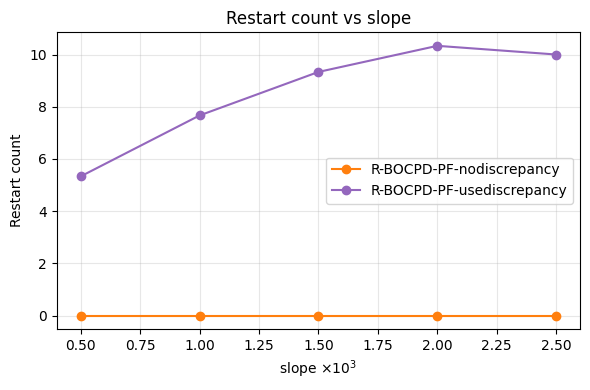

In [46]:
# from vis_utils import plot_restart
plot_restart(df, metric="slope", type="slope")

In [60]:
import torch
# data = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/slope_deltaCmp_v1/slope_0.002_seed456_batch20_results.pt", weights_only=False)
data = torch.load("C:/Users/yxu59/files/autumn2025/park/DynamicCalibration/figs/sudden_grid_outputs/v1/sudden_L120_delta3_bs20_seed456_results.pt", weights_only=False)

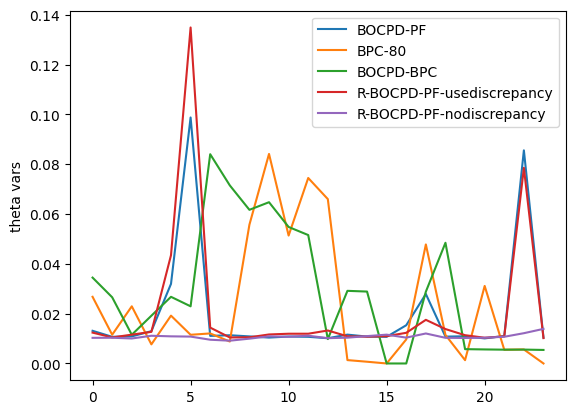

In [61]:
for name in data.keys():
    theta_vars = []
    pf_infos = []
    for i in range(len(data[name]["others"])):
        var = data[name]["others"][i]["var"]
        try:
            gini, ess, unique, entropy = data[name]["others"][i]["pf_info"][0]["gini"], \
                data[name]["others"][i]["pf_info"][0]["ess"], data[name]["others"][i]["pf_health_info"][0]["unique_ratio"], \
                    data[name]["others"][i]["pf_health_info"][0]["entropy_1d_histogram"]
        except:
            # entropy = data[name]["others"][i]["entropy"]
            entropy = None
            gini, ess, unique = None, None, None
        theta_vars.append(var)
        pf_infos.append((gini, ess, unique, entropy))
    theta_n = np.asarray(data[name]["theta"], dtype=float)
    theta_vars = np.asarray(theta_vars, dtype=float)
    plt.plot(theta_vars, label=name)
plt.legend()
plt.ylabel("theta vars")
plt.show()

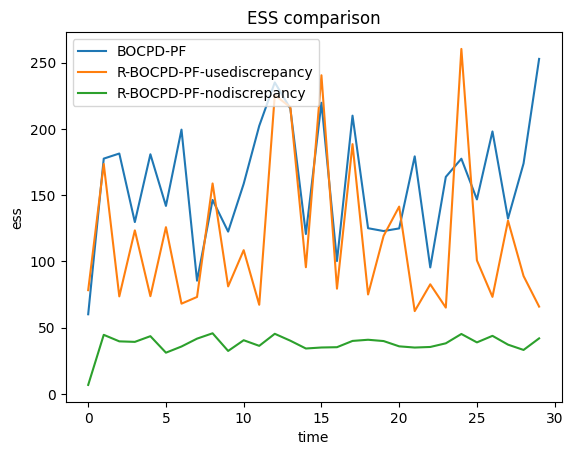

In [53]:
import pandas as pd
esses, ginis = {}, {}
theta_var_hist = {}
for name in data.keys():
    if "BOCPD-PF" in name:
        ess_list = []
        gini_list = []
        theta_var_list = []
        for i in range(len(data[name]["others"])):
            ess_list.append(data[name]["others"][i]["pf_info"][0]["ess"])
            gini_list.append(data[name]["others"][i]["pf_info"][0]["gini"])
            theta_var_list.append(data[name]["others"][i]["var"])
        esses[name] = ess_list
        ginis[name] = gini_list
        theta_var_hist[name] = theta_var_list
esses = pd.DataFrame(esses)
ginis = pd.DataFrame(ginis)
theta_var_hist = pd.DataFrame(theta_var_hist)
import matplotlib.pyplot as plt
for col in esses.columns:
    plt.plot(esses[col], label=col)

plt.legend()
plt.ylabel("ess")
plt.xlabel("time")
plt.title("ESS comparison")
plt.show()






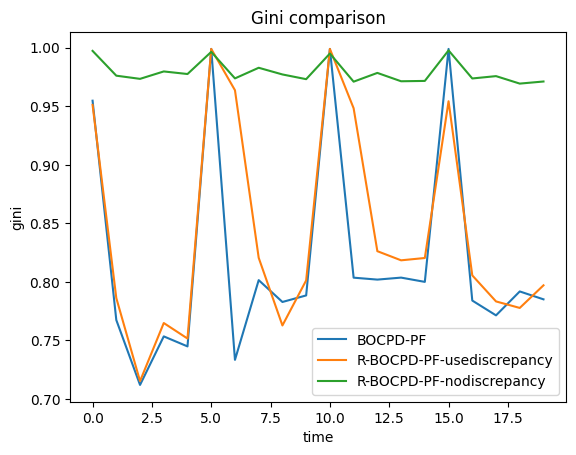

In [36]:
for col in ginis.columns:
    plt.plot(ginis[col], label=col)

plt.legend()
plt.ylabel("gini")
plt.xlabel("time")
plt.title("Gini comparison")
plt.show()

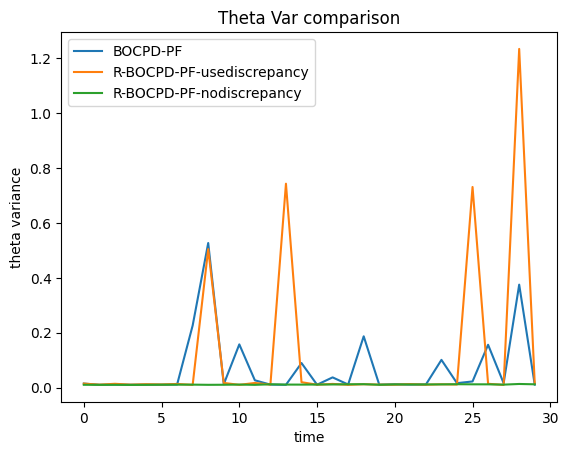

In [54]:
for col in theta_var_hist.columns:
    plt.plot(theta_var_hist[col], label=col)

plt.legend()
plt.ylabel("theta variance")
plt.xlabel("time")
plt.title("Theta Var comparison")
plt.show()

In [43]:
import numpy as np
for name in data.keys(): 
    if "BOCPD-PF" in name:  
        crps_hist = []
        for i in range(1,len(data[name]["others"])):
            crps_hist.append(data[name]["others"][i]["report_sub_hist"][0])
        print(name, "mean crps:", np.mean(crps_hist))

BOCPD-PF mean crps: 1.2386567553900352
R-BOCPD-PF-usediscrepancy mean crps: 1.2211701733017477
R-BOCPD-PF-nodiscrepancy mean crps: 1.2058988408271754


In [46]:
for name in data.keys(): 
    if "BOCPD-PF" in name:    
        ysim_var_hist = []
        for i in range(1, len(data[name]["others"])):
            ysim_var_hist.append(data[name]["others"][i]["report_sub_hist"][-1].mean())
        print(name, "mean ysim var:", np.mean(ysim_var_hist))

BOCPD-PF mean ysim var: 0.03761294802117402
R-BOCPD-PF-usediscrepancy mean ysim var: 0.03850469103945153
R-BOCPD-PF-nodiscrepancy mean ysim var: 0.03527743974791362


In [47]:
import torch

def analyze_experts(et, eps_w=1e-30):
    """
    Robust expert diagnostics for a single time step.

    et: list of dicts with keys:
      - 'logp': torch scalar or float
      - 'weight': float
      - (optional) 'log_mass'

    Returns dict with:
      - w_max
      - ess_expert
      - logp_mix
      - logp_top
      - delta_logp
      - contrib_frac
      - worst_frac
      - num_experts
    """

    E = len(et)
    if E == 0:
        return {
            "w_max": float("nan"),
            "ess_expert": float("nan"),
            "logp_mix": float("nan"),
            "logp_top": float("nan"),
            "delta_logp": float("nan"),
            "contrib_frac": [],
            "worst_frac": float("nan"),
            "num_experts": 0,
        }

    # Extract as tensors
    logp = torch.tensor([float(e["logp"]) for e in et], dtype=torch.float64)  # [E]
    w = torch.tensor([float(e["weight"]) for e in et], dtype=torch.float64)   # [E]

    # Normalize weights safely
    w_sum = w.sum()
    if w_sum <= 0:
        # fallback: uniform if all weights are zero/non-positive
        w = torch.full((E,), 1.0 / E, dtype=torch.float64)
    else:
        w = w / w_sum

    # Top expert
    w_max, top_idx = torch.max(w, dim=0)

    # Expert-level ESS
    ess_expert = 1.0 / torch.sum(w ** 2)

    # Mixture log predictive: logsumexp(log w + logp)
    w_safe = torch.clamp(w, min=eps_w)
    logp_mix = torch.logsumexp(torch.log(w_safe) + logp, dim=0)

    # Top logp
    logp_top = logp[top_idx]

    # For E=1, delta should be exactly 0 (numerically stable)
    if E == 1:
        delta_logp = torch.tensor(0.0, dtype=torch.float64)
        contrib_frac = torch.tensor([1.0], dtype=torch.float64)
        worst_frac = torch.tensor(1.0, dtype=torch.float64)
    else:
        delta_logp = logp_top - logp_mix

        # Probability-space contribution fractions
        contrib = w * torch.exp(logp)          # [E]
        denom = contrib.sum()
        if denom <= 0:
            contrib_frac = torch.full((E,), 1.0 / E, dtype=torch.float64)
        else:
            contrib_frac = contrib / denom

        worst_frac = torch.min(contrib_frac)

    return {
        "w_max": float(w_max),
        "ess_expert": float(ess_expert),
        "logp_mix": float(logp_mix),
        "logp_top": float(logp_top),
        "delta_logp": float(delta_logp),
        "contrib_frac": [float(x) for x in contrib_frac],
        "worst_frac": float(worst_frac),
        "num_experts": E,
    }


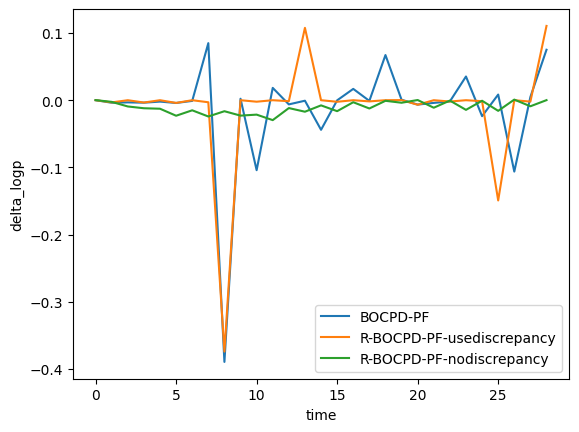

In [55]:
w_max = {}
delta_logp = {}
for name in data.keys():
    if "BOCPD-PF" in name:
        w_max_hist = []
        delta_logp_hist = []
        for i in range(1,len(data[name]["others"])):
            et = data[name]["others"][i]["report_sub_hist"][1]
            record = analyze_experts(et)
            w_max_hist.append(record["w_max"])
            delta_logp_hist.append(record["delta_logp"])
        w_max[name] = w_max_hist
        delta_logp[name] = delta_logp_hist

w_max = pd.DataFrame(w_max)
delta_logp = pd.DataFrame(delta_logp)

for col in delta_logp.columns:
    plt.plot(delta_logp[col], label=col)

plt.legend()
plt.ylabel("delta_logp")
plt.xlabel("time")
plt.show()



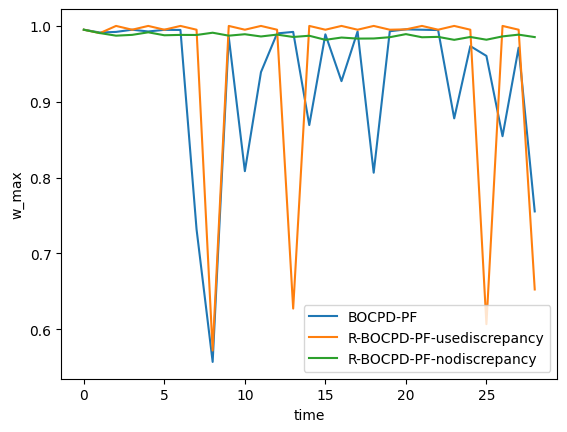

In [56]:
for col in w_max.columns:
    plt.plot(w_max[col], label=col)

plt.legend()
plt.ylabel("w_max")
plt.xlabel("time")
plt.show()